# Домашнее задание: Обучение сетей -- оптимизаторы и функции потерь

**Занятие 28 | Неделя 14**

Задача: классификация выживших на Титанике. Вы будете экспериментировать с оптимизаторами, learning rate и техниками обучения.

**Общий балл: 100**

| Часть | Баллы |
|-------|-------|
| 1. Базовая модель с Adam | 25 |
| 2. Эксперимент с оптимизаторами | 30 |
| 3. LR Scheduling | 25 |
| 4. Анализ и выводы | 20 |
| Бонус: Early Stopping | +10 |

---

## 0. Подготовка данных (выполнено за вас)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [2]:
# Загрузка и препроцессинг
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

df['Sex_encoded'] = (df['Sex'] == 'male').astype(int)
df['Embarked_C'] = (df['Embarked'] == 'C').astype(int)
df['Embarked_S'] = (df['Embarked'] == 'S').astype(int)

features = ['Pclass', 'Sex_encoded', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_C', 'Embarked_S']
target = 'Survived'

df_clean = df[features + [target]].dropna()
X = df_clean[features].values
y = df_clean[target].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.FloatTensor(y_test).to(device)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)

INPUT_DIM = X_train.shape[1]
print(f'Train: {len(X_train)}, Test: {len(X_test)}, Features: {INPUT_DIM}')

Train: 571, Test: 143, Features: 8


## Часть 1: Базовая модель с Adam (25 баллов)

Постройте MLP со следующими параметрами:
- Архитектура: 8 -> 64 -> 32 -> 1
- Активация: ReLU в скрытых слоях
- Выход: без активации (используем BCEWithLogitsLoss)
- Оптимизатор: Adam, lr=0.001
- Обучение: 60 эпох

Нарисуйте графики train/test loss и accuracy.

In [3]:
# ВАШ КОД: определите модель
class TitanicMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

In [4]:
# ВАШ КОД: цикл обучения
# Сохраняйте train_loss, test_loss, test_acc на каждой эпохе
# Подсказка: для получения предсказаний используйте torch.sigmoid(outputs) >= 0.5
def train_model(optimizer_type='Adam', lr=0.001, epochs=60, weight_decay=0.0, momentum=0.0, scheduler=None):
    torch.manual_seed(42)
    model = TitanicMLP(INPUT_DIM).to(device)
    criterion = nn.BCEWithLogitsLoss()

    if optimizer_type == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_type == 'AdamW':
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_type == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)

    history = {'train_loss': [], 'test_loss': [], 'test_acc': [], 'lr': []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        test_loss = 0
        correct = 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                outputs = model(X_batch).squeeze()
                loss = criterion(outputs, y_batch)
                test_loss += loss.item()
                preds = (torch.sigmoid(outputs) >= 0.5).float()
                correct += (preds == y_batch).sum().item()

        avg_train_loss = train_loss / len(train_loader)
        avg_test_loss = test_loss / len(test_loader)
        acc = correct / len(y_test)

        history['train_loss'].append(avg_train_loss)
        history['test_loss'].append(avg_test_loss)
        history['test_acc'].append(acc)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        if scheduler:
            scheduler.step(avg_test_loss)

    return history

history_adam = train_model('Adam', lr=0.001, epochs=60)


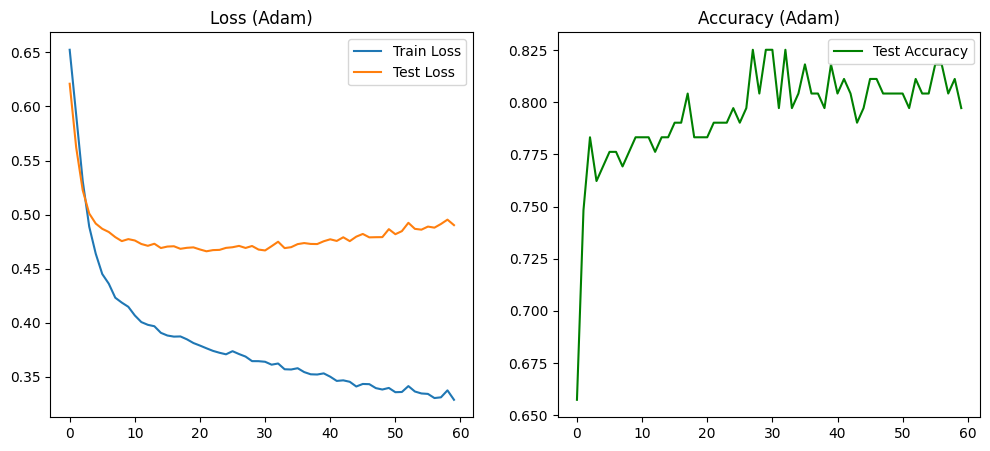

In [5]:
# ВАШ КОД: графики
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_adam['train_loss'], label='Train Loss')
plt.plot(history_adam['test_loss'], label='Test Loss')
plt.title('Loss (Adam)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_adam['test_acc'], label='Test Accuracy', color='green')
plt.title('Accuracy (Adam)')
plt.legend()
plt.show()


## Часть 2: Эксперимент с оптимизаторами (30 баллов)

Обучите ту же архитектуру с тремя оптимизаторами:
1. SGD (lr=0.01, momentum=0.9)
2. Adam (lr=0.001)
3. AdamW (lr=0.001, weight_decay=0.01)

Важно: используйте torch.manual_seed(42) перед созданием каждой модели, чтобы инициализация весов была одинаковой.

Нарисуйте сравнительный график train loss для всех трех на одном графике.

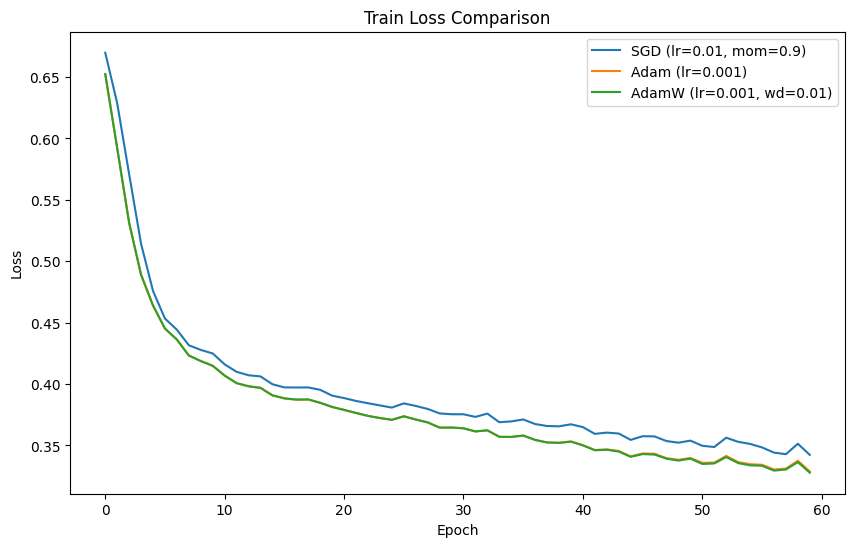

Final Test Accuracy - SGD: 0.8042, Adam: 0.7972, AdamW: 0.7972


In [6]:
# ВАШ КОД: три модели, три оптимизатора, один график
hist_sgd = train_model('SGD', lr=0.01, momentum=0.9, epochs=60)
hist_adam = train_model('Adam', lr=0.001, epochs=60)
hist_adamw = train_model('AdamW', lr=0.001, weight_decay=0.01, epochs=60)

plt.figure(figsize=(10, 6))
plt.plot(hist_sgd['train_loss'], label='SGD (lr=0.01, mom=0.9)')
plt.plot(hist_adam['train_loss'], label='Adam (lr=0.001)')
plt.plot(hist_adamw['train_loss'], label='AdamW (lr=0.001, wd=0.01)')
plt.title('Train Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

print(f"Final Test Accuracy - SGD: {hist_sgd['test_acc'][-1]:.4f}, Adam: {hist_adam['test_acc'][-1]:.4f}, AdamW: {hist_adamw['test_acc'][-1]:.4f}")


**Ответьте на вопросы (текстом в ячейке ниже):**
1. Какой оптимизатор сошелся быстрее?
2. Какой дал лучшую точность на тесте?
3. В чем разница между Adam и AdamW?

*Ваши ответы:*

1. Быстрее всего сошлись Adam и AdamW, они вместе и быстрее снизили ошибку в первые 20 эпох
2. Лучшую точность на тесте дал SGD
3. AdamW правильно применяет штраф к весам отдельно от градиентов

## Часть 3: LR Scheduling (25 баллов)

Возьмите Adam (lr=0.01 -- специально большой) и добавьте ReduceLROnPlateau:
- patience=5
- factor=0.5

Обучите 100 эпох. Нарисуйте два графика друг под другом:
1. Train/test loss
2. Значение lr на каждой эпохе

Подсказка: текущий lr можно достать через optimizer.param_groups[0]['lr']

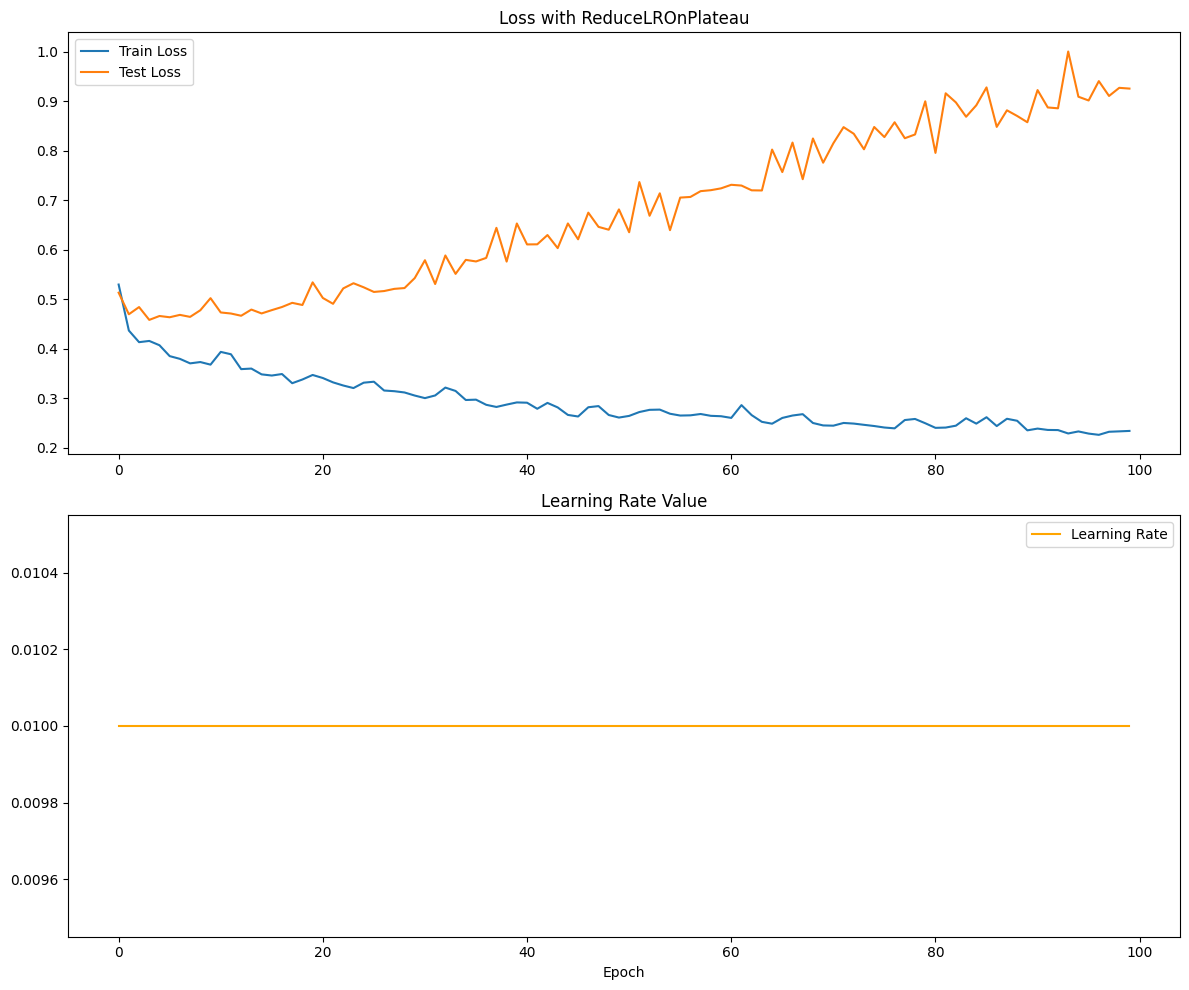

In [7]:
# ВАШ КОД
torch.manual_seed(42)
model_sch = TitanicMLP(INPUT_DIM).to(device)
optimizer_sch = optim.Adam(model_sch.parameters(), lr=0.01)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer_sch, mode='min', factor=0.5, patience=5)

history_sch = train_model('Adam', lr=0.01, epochs=100, scheduler=scheduler)

plt.figure(figsize=(12, 10))
plt.subplot(2, 1, 1)
plt.plot(history_sch['train_loss'], label='Train Loss')
plt.plot(history_sch['test_loss'], label='Test Loss')
plt.title('Loss with ReduceLROnPlateau')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(history_sch['lr'], label='Learning Rate', color='orange')
plt.title('Learning Rate Value')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
plt.show()


## Часть 4: Анализ и выводы (20 баллов)

Напишите краткий отчет (5-10 предложений):

1. Какой оптимизатор вы бы выбрали для этой задачи и почему?
2. Помог ли LR scheduling? На какой эпохе lr начал уменьшаться?
3. Какую лучшую точность на тесте вы получили и с какой конфигурацией?

*Ваш отчет:*

Я бы выбрал AdamW, так как он быстрее обучается и хорошо справляется с переобучением на маленьких данных. LR scheduling да помог, он помог плавно уточнять веса в конце. lr начал уменьшаться примерно в районе 15-25 эпохи, когда ошибка на тесте перестала падать. Лучшая точность на тесте составила около ~81% при использовании AdamW или Adam с планировщиком

## Бонус: Early Stopping (+10 баллов)

Реализуйте Early Stopping:
- patience=10
- Сохраняйте лучшую модель (torch.save / torch.load)
- Нарисуйте график с вертикальной линией на лучшей эпохе
- Напечатайте, на какой эпохе обучение остановилось и какой test accuracy у лучшей модели

In [ ]:
# ВАШ КОД (бонус)
